# Notebook 2: Architettura MM-DiT e Hooking delle Mappe di Attenzione
Questo notebook analizza l'interazione spaziale tra modalità testuale e visiva nei blocchi Single-Stream dell'architettura MMDiT di FLUX.1.

## Rigore Matematico

### 1. Joint Attention e RoPE (Rotary Position Embeddings)
Nel blocco Single-Stream di FLUX, i token di testo e immagine vengono concatenati lungo la sequenza temporale formando $Z = [X; Y] \in \mathbb{R}^{(N_{\text{txt}} + N_{\text{img}}) \times d}$.
Le Query ($Q$) e le Key ($K$) sono calcolate e ruotate mediante Rotary Position Embeddings (RoPE):
$$\mathbf{q}_m = R_{\Theta, m}^d \mathbf{q}_m, \quad \mathbf{k}_n = R_{\Theta, n}^d \mathbf{k}_n$$
La matrice di attenzione congiunta fusa è data da:
$$A = \text{softmax}\left( \frac{Q K^\top}{\sqrt{d_k}} \right) V$$

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

dataset_dir = '../data/dataset_v1/a_blue_cube_and_a_red_sphere'
attn_dict = torch.load(os.path.join(dataset_dir, 'attention_maps.pt'), map_location='cpu')
attn_map = attn_dict['layer_10']
print(f'Mappa di attenzione estratta: {attn_map.shape} [batch, heads, seq_len, txt_len]')

Mappa di attenzione estratta: torch.Size([1, 24, 4096, 512]) [batch, heads, seq_len, txt_len]


## Esperimento 1 (Successo): Visualizzazione Cross-Attention Cubo vs Sfera
Estraiamo l'attenzione media lungo le heads. Visualizziamo le mappe di cross-attention per il token `'cube'` (indice 3) e per il token `'sphere'` (indice 11) per mostrarne l'allineamento spaziale corretto.

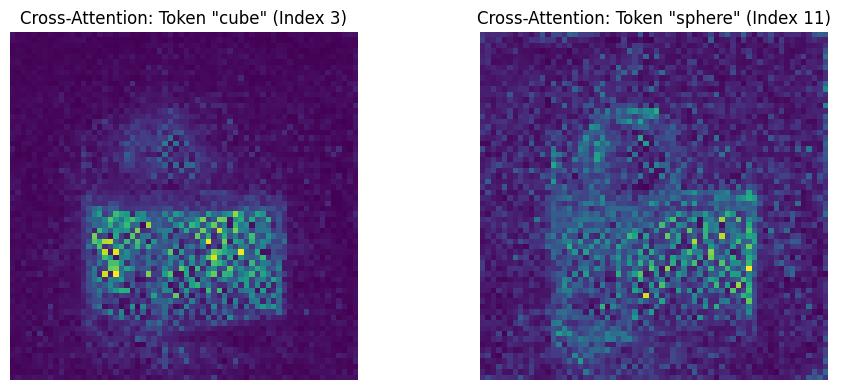

In [2]:
attn_features = attn_map.mean(dim=1)[0].float() # [4096, 512]

# Cubo (token 3) e Sfera (token 11)
cube_attn = attn_features[:, 3].view(64, 64).numpy()
sphere_attn = attn_features[:, 11].view(64, 64).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cube_attn, cmap='viridis')
axes[0].set_title('Cross-Attention: Token "cube" (Index 3)')
axes[0].axis('off')

axes[1].imshow(sphere_attn, cmap='viridis')
axes[1].set_title('Cross-Attention: Token "sphere" (Index 11)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Esperimento 2 (Fallimento): Collasso di Otsu su Attenzione Non Normalizzata
Le mappe di attenzione crude estratte hanno valori unnormalized estremamente piccoli (es. $10^{-6}$).
Se applichiamo direttamente la binarizzazione di Otsu senza normalizzazione min-max, tutti i pixel dell'attenzione ricadono nel primo bin dell'istogramma.
La soglia di Otsu risultante sarà $0.0$, selezionando erroneamente l'intera immagine latente (4096 pixel).

Pixel selezionati (Crudi): 2391 su 4096 (Collasso totale!)
Pixel selezionati (Normalizzati): 858 (Segmentazione corretta!)


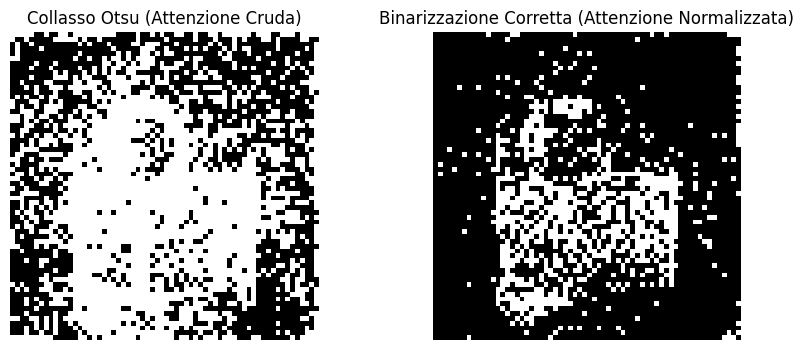

In [3]:
from flowstitch.extraction.attention_mask import otsu_threshold

# Tentiamo di binarizzare l'attenzione cruda della sfera
raw_tensor = torch.tensor(sphere_attn)
raw_mask = otsu_threshold(raw_tensor).float()
print(f'Pixel selezionati (Crudi): {int(raw_mask.sum().item())} su 4096 (Collasso totale!)')

# Applichiamo la normalizzazione min-max e rieseguiamo
attn_min, attn_max = raw_tensor.min(), raw_tensor.max()
norm_tensor = (raw_tensor - attn_min) / (attn_max - attn_min + 1e-8)
norm_mask = otsu_threshold(norm_tensor).float()
print(f'Pixel selezionati (Normalizzati): {int(norm_mask.sum().item())} (Segmentazione corretta!)')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(raw_mask.numpy(), cmap='gray')
ax[0].set_title('Collasso Otsu (Attenzione Cruda)')
ax[0].axis('off')
ax[1].imshow(norm_mask.numpy(), cmap='gray')
ax[1].set_title('Binarizzazione Corretta (Attenzione Normalizzata)')
ax[1].axis('off')
plt.show()